(56, 9) (39, 9)


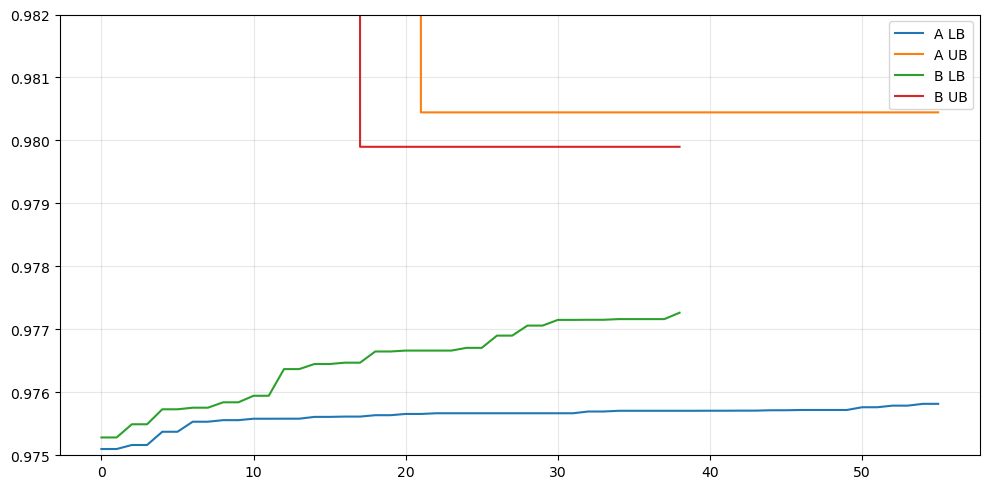

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

csv_a = "snog_1e3_TL15_6h.csv"
csv_b = "snog_1e3_TL30_6h.csv"

ymin, ymax = 0.975, 0.982

A = pd.read_csv(csv_a)
B = pd.read_csv(csv_b)
print(A.shape, B.shape)

def pick(df, want):
    for c in df.columns:
        n = "".join(ch for ch in str(c).lower() if ch.isalnum())
        if any(k in n for k in want):
            s = pd.to_numeric(df[c], errors="coerce")
            if s.notna().mean() > 0.5:
                return c
    raise ValueError(f"Can't find column for {want}. Columns={list(df.columns)}")

lbA, ubA = pick(A, ["lb","lowerbound","dualbound","zlb"]), pick(A, ["ub","upperbound","primalbound","zub"])
lbB, ubB = pick(B, ["lb","lowerbound","dualbound","zlb"]), pick(B, ["ub","upperbound","primalbound","zub"])

plt.figure(figsize=(10,5))
plt.plot(pd.to_numeric(A[lbA], errors="coerce"), label=f"A {lbA}")
plt.plot(pd.to_numeric(A[ubA], errors="coerce"), label=f"A {ubA}")
plt.plot(pd.to_numeric(B[lbB], errors="coerce"), label=f"B {lbB}")
plt.plot(pd.to_numeric(B[ubB], errors="coerce"), label=f"B {ubB}")

if ymin is not None or ymax is not None:
    plt.ylim(ymin, ymax)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
